In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('student_info.csv')
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [ ]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [ ]:
df.isnull().sum()

,0
study_hours,5
student_marks,0


In [ ]:
df["study_hours"]=df["study_hours"].fillna(df["study_hours"].mean())

In [ ]:
df.isnull().sum()

,0
study_hours,0
student_marks,0


Text(0, 0.5, 'student_marks')

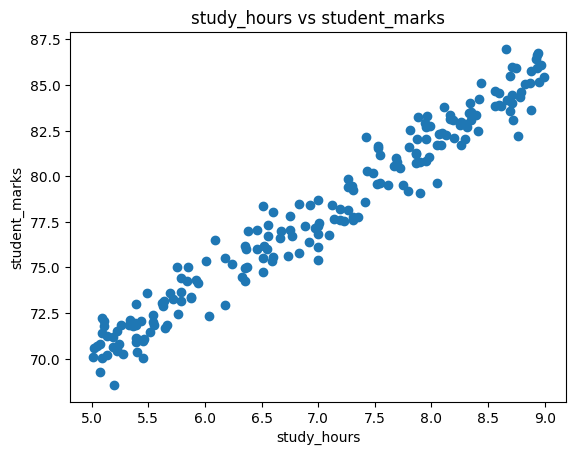

In [ ]:
plt.scatter(df.study_hours,df.student_marks)
plt.title("study_hours vs student_marks")
plt.xlabel("study_hours")
plt.ylabel("student_marks")

In [ ]:
x=df[["study_hours"]]
y=df["student_marks"]
print(x)
print(y)

     study_hours
0       6.830000
1       6.560000
2       6.995949
3       5.670000
4       8.670000
..           ...
195     7.530000
196     8.560000
197     8.940000
198     6.600000
199     8.350000

[200 rows x 1 columns]
0      78.50
1      76.74
2      78.68
3      71.82
4      84.19
       ...  
195    81.67
196    84.68
197    86.75
198    78.05
199    83.50
Name: student_marks, Length: 200, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=51)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
x_test.head()

,study_hours
148,8.30
104,7.23
4,8.67
7,8.99
192,8.71


In [ ]:
model.predict(x_test)

array([83.11381458, 78.9025963 , 84.57003024, 85.82946001, 84.72745896,
       80.75238377, 72.84159055, 71.66087515, 73.23516235, 71.66087515,
       73.47130543, 76.38373677, 73.23516235, 73.58937697, 82.95638585,
       70.40144538, 73.23516235, 78.74516758, 75.55723598, 82.68088559,
       76.65923703, 70.48015974, 74.77009238, 77.98143645, 85.59331693,
       82.56281405, 76.42309395, 85.0423164 , 78.39095296, 81.38209865,
       81.73631327, 83.15317176, 82.20859943, 81.10659839, 73.58937697,
       71.1492318 , 71.89701823, 81.53952737, 72.60544747, 71.93637541])

In [ ]:
y_test.head()

,student_marks
148,82.02
104,77.55
4,84.19
7,85.46
192,84.03


In [ ]:
model.score(x_test,y_test)

0.9514124242154466

Text(0, 0.5, 'student_marks')

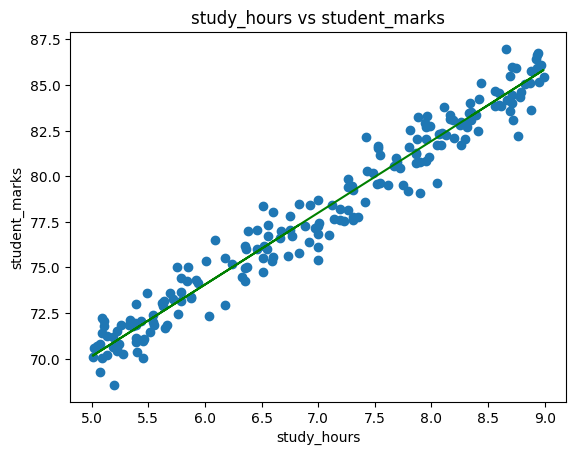

In [ ]:
plt.scatter(df.study_hours,df.student_marks)
plt.plot(df.study_hours,model.predict(x),color="green")
plt.title("study_hours vs student_marks")
plt.xlabel("study_hours")
plt.ylabel("student_marks")

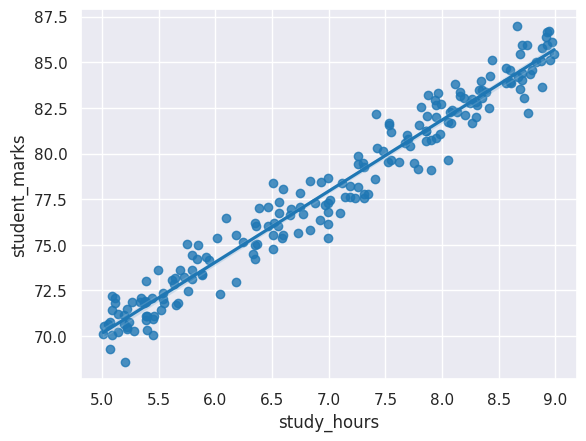

In [ ]:
import seaborn as sns
sns.regplot(data=df,x="study_hours",y="student_marks")
sns.set_style("darkgrid")

In [ ]:
# checking the regression equation
def student_marks1(student_hour):
   predict=model.predict([[student_hour]])
   return predict

In [ ]:
student_marks1(7)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([77.99738115])

In [ ]:
m=model.coef_
m

array([3.93571802])

In [ ]:
c=model.intercept_
c

np.float64(50.44735503694244)

In [ ]:
ans=7*m+c
ans

array([77.99738115])

# Multiple linear Regression


In [ ]:
df1=pd.read_csv("/content/Student_Performance (2).csv")
df1

,hours,scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   hours                             10000 non-null  int64 
 1   scores                            10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [ ]:
df1["Extracurricular Activities"]=df1["Extracurricular Activities"].map({"Yes":1,"No":0})
df1

,hours,scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91
1,4,82,0,4,2,65
2,8,51,1,7,2,45
3,5,52,1,5,2,36
4,7,75,0,8,5,66
...,...,...,...,...,...,...
9995,1,49,1,4,2,23
9996,7,64,1,8,5,58
9997,6,83,1,8,5,74
9998,9,97,1,7,0,95


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   hours                             10000 non-null  int64
 1   scores                            10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  int64
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(6)
memory usage: 468.9 KB


In [ ]:
x=df1.drop(["Performance Index"],axis=1)

In [ ]:
x.shape

(10000, 5)

In [ ]:
x.head()

,hours,scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5


In [ ]:
y=df1["Performance Index"]
y.head()

,Performance Index
0,91
1,65
2,45
3,36
4,66


In [ ]:
y.shape

(10000,)

In [ ]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(x_train,y_train)

LinearRegression()

In [ ]:
LR.predict(x_test)

array([34.25332212, 25.48435261, 57.85578617, ..., 44.85324756,
       20.76334281, 22.32167261])

In [ ]:
accuracy=LR.score(x_test,y_test)*100
accuracy

98.86293742111494

In [ ]:
intercept=LR.coef_
intercept

array([2.85587953, 1.02411464, 0.62226177, 0.49218895, 0.20052196])

In [ ]:
slope=LR.intercept_
slope

np.float64(-34.65562543930535)